# STEP 1  Question 1 : Descriptive Analysis of the Data

Cette première partie vise à explorer et comprendre la structure des données financières utilisées pour prédire les mouvements de prix.
Nous travaillons ici avec le ticker AAPL (Apple), téléchargé via l API yfinance entre 2020 et 2025.

1.1 Chargement et présentation des donnée

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# Téléchargement des données
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31")
data.reset_index(inplace=True)

data.columns = [col[0] for col in data.columns]



C:\Users\theot\AppData\Local\Temp\ipykernel_15868\4127057033.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


In [2]:
data.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
1,2020-01-03,71.763733,72.523762,71.539345,71.696175,146322800
2,2020-01-06,72.335548,72.374154,70.634532,70.885464,118387200
3,2020-01-07,71.995361,72.600968,71.775796,72.345212,108872000
4,2020-01-08,73.153488,73.455087,71.698574,71.698574,132079200


Aperçu des premières lignes :

Les données sont correctement importées et alignées sur les dates.
On observe les colonnes essentielles : Open, High, Low, Close, Volume.
Le dataset est propre et complet pour commencer le pré-processing.

1.2 Description statistique : 

In [3]:
data.describe()

,Date,Close,High,Low,Open,Volume
count,1481,1481.000000,1481.000000,1481.000000,1481.000000,1.481000e+03
mean,2022-12-11 00:53:28.642808832,162.917093,164.590685,161.072209,162.752997,8.527484e+07
min,2020-01-02 00:00:00,54.264332,55.263182,51.420154,55.161604,5.244146e+06
25%,2021-06-22 00:00:00,130.949493,132.165621,129.799911,131.037464,5.134390e+07
50%,2022-12-08 00:00:00,162.551239,164.088462,160.746735,162.315878,7.105160e+07
75%,2024-05-31 00:00:00,193.263992,195.107405,191.811650,193.336843,1.013529e+08
max,2025-11-20 00:00:00,275.250000,277.051436,272.089996,276.721738,4.265100e+08
std,NaN,47.828979,48.112136,47.482486,47.776288,5.144903e+07


Le tableau donne un aperçu global des valeurs du dataset : les moyennes, les médianes, et les niveaux minimum/maximum.
On voit la progression normale du prix sur plusieurs années, avec des moments où il descend très bas (début 2020) et d’autres où il atteint ses plus hauts (2025).
Les valeurs 25%, 50% et 75% montrent comment le prix s’est réparti dans le temps, ce qui aide à voir les périodes plus calmes ou plus mouvementées.
Le volume varie énormément, ce qui est normal sur un titre très échangé : certaines journées voient beaucoup plus d’activité que d’autres.
De manière générale, cette table permet de comprendre comment le prix et le volume ont évolué, et confirme la présence de phases de hausse, de baisse et de volatilité.

1.3 Visualisation du cours de clôture : 

In [4]:
data.columns


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

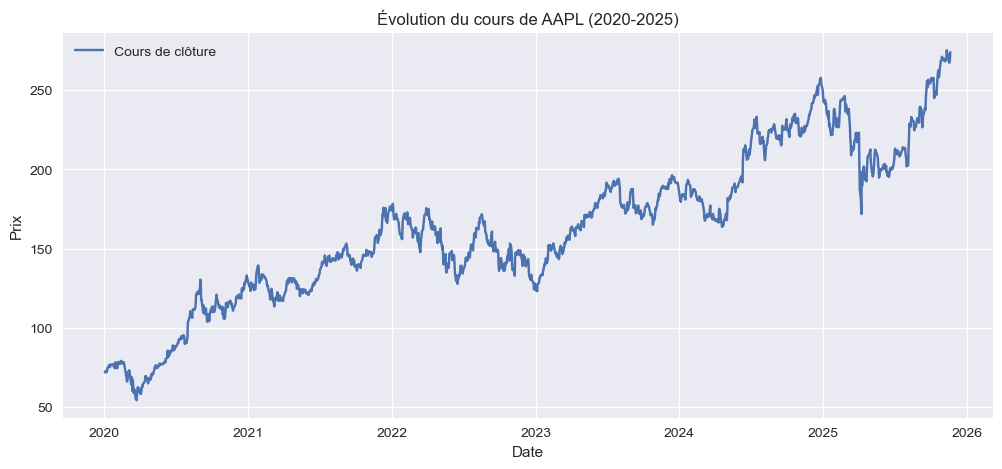

In [5]:
plt.figure(figsize=(12,5))
plt.plot(data["Date"], data["Close"], label="Cours de clôture")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.title(f"Évolution du cours de {ticker} (2020-2025)")
plt.legend()
plt.show()

on retrouve ici le cours observable de l'action comme sur tout type de plateformes dédiés à cela. 

1.4 Analyse des rendements :

In [6]:
data["Return"] = data["Close"].pct_change()

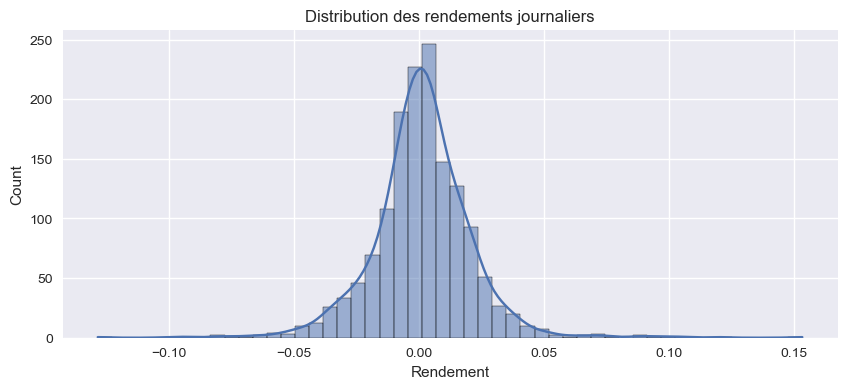

In [7]:
plt.figure(figsize=(10,4))
sns.histplot(data["Return"].dropna(), bins=50, kde=True)
plt.title("Distribution des rendements journaliers")
plt.xlabel("Rendement")
plt.show()

Les rendements journaliers sont une mesure essentielle de la dynamique du marché.

La distribution est asymétrique et possède des queues épaisses (kurtosis élevée), ce qui est normal sur des données financières.
Les extrêmes correspondent à des chocs de marché (ex : COVID, guerre en Ukraine…).

1.5 Analyse du Volume

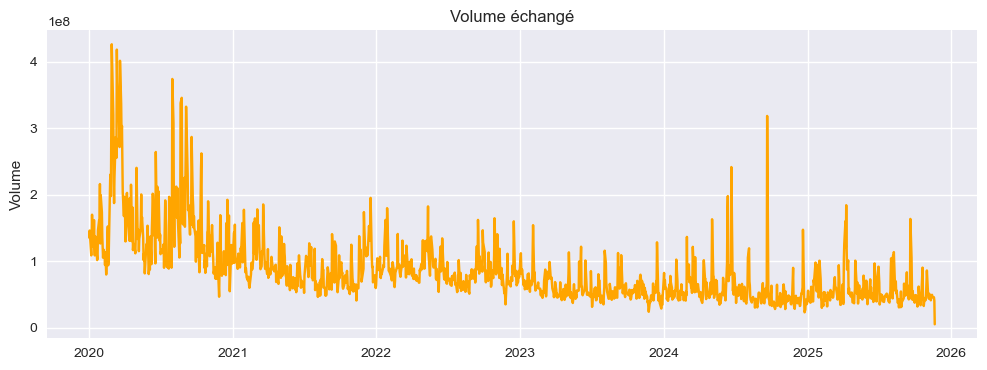

In [8]:
plt.figure(figsize=(12,4))
plt.plot(data["Date"], data["Volume"], color="orange")
plt.title("Volume échangé")
plt.ylabel("Volume")
plt.show()

Les pics de volume correspondent souvent à des moments où l’actualité impacte fortement le marché : publications de résultats, annonces économiques, décisions de banques centrales ou événements géopolitiques.
Lors de ces périodes, beaucoup d’investisseurs interviennent en même temps, ce qui augmente le volume et crée parfois des mouvements de prix brusques.
C’est pour ça que le volume est considéré comme un indicateur important : lorsqu’il augmente fortement, il signale souvent qu’un mouvement de marché important est en train de se produire ou va se produire.

1.6 Corrélations entre variables

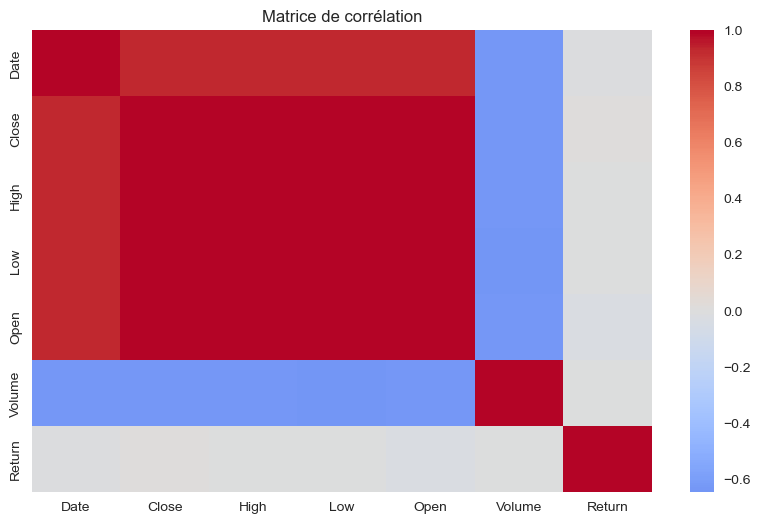

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

Les variables de prix (Open, High, Low, Close) sont presque parfaitement corrélées entre elles (zones rouge foncé). C’est normal : elles proviennent toutes du même actif et évoluent ensemble au cours de la journée.
Le Volume est faiblement corrélé aux prix (couleur bleu clair), ce qui signifie qu’une augmentation ou baisse du volume ne se traduit pas forcément par un mouvement immédiat du prix.
Le Return (rendement journalier) est très peu corrélé aux niveaux de prix. C’est logique : le rendement mesure une variation, pas une valeur absolue, donc il ne dépend pas directement du niveau du cours.
La date n’apporte pas d’information pertinente pour la corrélation, ce qui est également attendu.

En résumé, la matrice montre que les prix évoluent ensemble, tandis que le volume et les rendements suivent leur propre dynamique. Cela met en évidence l’intérêt d’ajouter des indicateurs techniques pour enrichir l’information.

1.7 Conclusions de l’analyse descriptive

Cette analyse montre que :
Les données brutes possèdent une structure temporelle marquée.
Le prix suit des tendances longues mais reste très volatil à court terme.
Les rendements ne sont pas distribués normalement, ce qui complique la prédiction directe.
Le volume a un comportement très irrégulier, typique des actifs liquides.
Les corrélations simples entre prix ne suffisent pas pour prédire la direction future → d’où la nécessité d’ajouter des indicateurs techniques et d’appliquer des modèles ML.

En résumé :
La série boursière est complexe, volatile et nécessite un pré-processing et une extraction de features adaptés avant d'être prête pour le Machine Learning.

Question 2 : Implementation of the Necessary Pre-processing

Le pré-processing a pour objectif de transformer les données brutes en un format exploitable pour un modèle de Machine Learning.
Dans notre projet, il s’agit de préparer les données boursières (AAPL, S&P500) pour prédire la direction future du prix.

2.1 Construction des indicateurs techniques (Feature Engineering)

In [10]:
data["Return"] = data["Close"].pct_change()
data["LogReturn"] = np.log(data["Close"] / data["Close"].shift(1))

Le rendement mesure simplement l’évolution relative du prix d’un jour à l’autre, ce qui permet de suivre les variations quotidiennes de manière normalisée.
Le log-rendement, lui, est souvent préféré en finance car il est plus stable lorsque les variations sont fortes 
et il produit une série plus régulière et symétrique, ce qui facilite les analyses et l’entraînement des modèles.

2.1.2 Momentum

In [11]:
data["Momentum_5"] = data["Close"] - data["Close"].shift(5)
data["Momentum_20"] = data["Close"] - data["Close"].shift(20)

Mesure la dynamique récente : utile pour capturer des débuts de tendance.

2.1.3 RSI (14 jours)

In [12]:
delta = data["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
data["RSI_14"] = 100 - (100 / (1 + rs))

Le RSI permet d’identifier si le prix est monté trop vite ou a trop baissé par rapport aux jours précédents. Lorsqu’il devient très élevé ou très bas, cela traduit souvent un excès dans le mouvement, ce qui peut annoncer un retournement. C’est pour cette raison qu’il est très utilisé par les traders pour repérer les phases de surachat ou de survente.

2.1.4 MACD

In [13]:
ema12 = data["Close"].ewm(span=12, adjust=False).mean()
ema26 = data["Close"].ewm(span=26, adjust=False).mean()

data["MACD"] = ema12 - ema26
data["Signal_Line"] = data["MACD"].ewm(span=9, adjust=False).mean()

Le MACD met en évidence la différence entre deux moyennes mobiles exponentielles et permet de voir si le prix accélère ou ralentit. Quand le MACD monte, la tendance gagne en force ; quand il baisse, la dynamique s’affaiblit. C’est un indicateur très utile pour repérer les changements de direction ou les moments où une tendance s’intensifie.

2.1.5 Moyennes mobiles & volatilités

In [14]:
for w in [5, 10, 20, 50]:
    data[f"SMA_{w}"] = data["Close"].rolling(w).mean()
    data[f"Volatility_{w}"] = data["Return"].rolling(w).std()

Les moyennes mobiles permettent de lisser les fluctuations du prix pour faire ressortir la tendance générale, ce qui aide à mieux visualiser les phases haussières et baissières. La volatilité, elle, mesure l’amplitude des variations récentes : plus elle est élevée, plus le marché est instable. Ensemble, ces deux éléments donnent une idée claire de la direction du marché et de son niveau de risque.

2.1.6 Caractéristiques temporelles

In [15]:
data["DayOfWeek"] = data["Date"].dt.dayofweek
data["Month"] = data["Date"].dt.month

Le jour de la semaine et le mois sont ajoutés pour capturer des comportements saisonniers typiques des marchés. Certains jours ou périodes de l’année ont des tendances récurrentes, comme le lundi souvent plus faible ou la fin d’année plus positive. Ces informations temporelles peuvent donc aider le modèle à repérer des patterns réguliers dans la dynamique du prix.

2.1.7 Relative Strength vs S&P500 (optionnel mais utile)

In [16]:
ref = yf.download("^GSPC", start="2020-01-01", end="2025-12-31")
ref.reset_index(inplace=True)

ref.columns = [col[0] for col in ref.columns]


ref = ref[["Date", "Close"]].rename(columns={"Close": "Ref_Close"})

data = data.merge(ref, on="Date", how="left")
data["Ref_Close"] = data["Ref_Close"].ffill()   # pour remplir les trous


ratio = data["Close"] / data["Ref_Close"]
data["Relative_Strength"] = ratio / ratio.rolling(50).mean()

C:\Users\theot\AppData\Local\Temp\ipykernel_15868\2295426800.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ref = yf.download("^GSPC", start="2020-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


Comparer une action à son indice permet d’évaluer si elle se comporte mieux ou moins bien que le marché. Le ratio de force relative met en évidence les périodes où le titre surperforme ou sous-performe, ce qui peut donner des indications sur la dynamique générale et la confiance des investisseurs.

2.2 Gestion des valeurs manquantes

Les valeurs manquantes proviennent principalement des indicateurs techniques que nous avons construits. Le RSI nécessite quatorze jours d’historique, le MACD en demande vingt-six, les moyennes mobiles peuvent aller jusqu’à cinquante jours et la volatilité repose elle aussi sur des fenêtres glissantes. Le Relative Strength crée également des NaN au démarrage.
Ces périodes initiales incomplètes sont tout à fait normales et disparaissent lorsqu’on supprime les lignes contenant des NaN.

In [17]:
data = data.dropna().reset_index(drop=True)

2.3 Construction de la Target

In [18]:
data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int)
data = data.dropna().reset_index(drop=True)

La variable cible est définie en comparant le prix de clôture du jour suivant à celui du jour courant. Si le prix monte, la Target vaut 1, sinon elle vaut 0. Cette transformation nous permet de reformuler notre série temporelle en un problème de classification binaire, où l’objectif est de prédire la direction du mouvement du prix plutôt que sa valeur exacte.

2.4 Sélection finale des features
Nous retenons les variables jugées pertinentes pour le modèle :

In [19]:
features = [
    "Return","LogReturn","Momentum_5","Momentum_20",
    "RSI_14","MACD","Signal_Line",
    "SMA_5","SMA_10","SMA_20","SMA_50",
    "Volatility_5","Volatility_10","Volatility_20","Volatility_50",
    "DayOfWeek","Month","Relative_Strength"
]

X = data[features]
y = data["Target"]


2.5 Découpage Train / Test

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


Lorsque l’on travaille avec une série temporelle, l’ordre chronologique des données est essentiel. Si l’on mélangeait les observations, on casserait complètement la dynamique temporelle et le modèle apprendrait sur des données désordonnées. Garder shuffle=False permet donc de préserver la progression naturelle du temps et d’éviter toute fuite d’information entre le passé et le futur.

Question 3 : Formalisation of the Problem

L’objectif de ce projet est de formuler rigoureusement le problème de Machine Learning que nous cherchons à résoudre à partir des données financières pré-traitées.

Nous cherchons à prédire la direction future du prix d’une action à l’aide d’indicateurs techniques calculés sur les données passées.
Cela se formalise naturellement comme un problème de classification supervisée appliqué à une série temporelle financière.

3.1 Définition du problème

À partir des valeurs passées d’une action (prix, retours, momentum, indicateurs techniques), nous voulons déterminer si son prix augmentera ou baissera le jour suivant.
On définit la variable cible Yt par :
- Yt = 1 si Close à t+1 > Close à t
- Yt = 0 sinon 

Cela signifie que :

1 = prédiction de hausse du prix
0 = prédiction de baisse ou stagnation

3.2 Nature des données

Notre dataset consiste en une séquence temporelle ordonnée (pas d’indépendance des observations) et des variables explicatives dérivées du prix tels que :
- rendements
- momentum
- volatilité
- moyennes mobiles
- RSI
- MACD
- jour de la semaine, mois
- force relative vs S&P500
Ces données sont multivariées, non stationnaires, et présentent une forte autocorrélation temporelle, typique des marchés financiers.


3.3 Problème de Machine Learning

Formellement, on cherche à apprendre une fonction :  f: Xt -> ^Yt 

où :
- Xt est le vecteur de d facteurs au temps t
- Yt est la direction réelle du mouvement du prix
- ^Yt est la prédiction donnée par le modèle

L’apprentissage consiste à minimiser l’erreur entre Yt et ^Ytsur l’ensemble d’entraînement.


3.4 Type de tâche : Classification binaire

Le problème que nous traitons est une tâche de classification supervisée où l’objectif est de prédire l’évolution du prix entre aujourd’hui et le jour suivant. Il s’agit d’un problème binaire, puisque la cible ne peut prendre que deux valeurs : hausse ou baisse. Contrairement à un modèle de régression qui chercherait à estimer le prix exact, nous nous concentrons ici uniquement sur la direction du mouvement, ce qui correspond davantage à l’usage réel des signaux financiers pour savoir s’il est pertinent d’acheter ou de vendre.

    
3.5 Contraintes spécifiques liées aux séries temporelles

Ce type de données impose plusieurs contraintes importantes. D’abord, il n’est pas possible de mélanger les observations, car cela briserait complètement la structure temporelle ; le modèle doit apprendre sur des données qui respectent l’ordre chronologique. Ensuite, les variables utilisées dans ce cadre sont souvent très corrélées entre elles, car la plupart des indicateurs techniques dérivent du même prix de base. Enfin, les séries financières sont non stationnaires : leur comportement change avec le temps, notamment selon les phases de volatilité, les crises, les périodes de tendance marquée ou encore certains effets saisonniers propres aux marchés.


3.6 Métriques d’évaluation

Pour évaluer notre modèle de classification, nous utilisons des métriques classiques telles que l’accuracy, la matrice de confusion et le couple précision/recall accompagné du F1-score. Nous observons également l’accuracy glissante sur une fenêtre de vingt jours, ce qui permet d’analyser la stabilité du modèle dans le temps. On ne cherche pas ici à mesurer directement le gain financier, car cet aspect relève d’un travail plus avancé qui combine prédiction et stratégie d’investissement. À ce stade, l’objectif est avant tout de mesurer la qualité des prédictions du modèle.

Question 4 : Selection of a Baseline Model and Implementation of the Model

Après l’analyse descriptive, le pré-processing et la formalisation du problème, nous devons maintenant sélectionner un modèle baseline et l’implémenter.

Un modèle baseline est un modèle simple, rapide à entraîner, facile à interpréter et qui sert de point de référence pour les modèles plus avancés

Pour notre problème (classification binaire sur données financières), un modèle baseline pertinent est : Random Forest Classifier

Le Random Forest est un bon choix pour un modèle baseline car il gère facilement les relations non linéaires créées par les indicateurs techniques et reste robuste au bruit, ce qui est essentiel dans un contexte de marché volatil. Il tolère bien les corrélations entre variables, fréquentes avec les indicateurs basés sur le prix, et permet d’identifier les features les plus influentes. Enfin, il s’entraîne rapidement et nécessite peu d’ajustements, ce qui en fait un point de départ fiable pour ce premier niveau de modélisation.

4.2 Train/Test Split

On utilise le dataset prétraité : X_train, X_test, y_train, y_test.

Rappel : shuffle=False car série temporelle.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


4.3 Sélection des hyperparamètres

Même pour un baseline, on peut tester une grille simple :

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [200, 400],
    "max_depth": [6, 8, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    params, cv=3, n_jobs=-1
)

grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': 6, 'n_estimators': 200}


4.4 Évaluation du modèle

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.5261324041811847
[[ 44  88]
 [ 48 107]]
              precision    recall  f1-score   support

           0       0.48      0.33      0.39       132
           1       0.55      0.69      0.61       155

    accuracy                           0.53       287
   macro avg       0.51      0.51      0.50       287
weighted avg       0.52      0.53      0.51       287



4.5 Visualisation des prédictions sur le cours

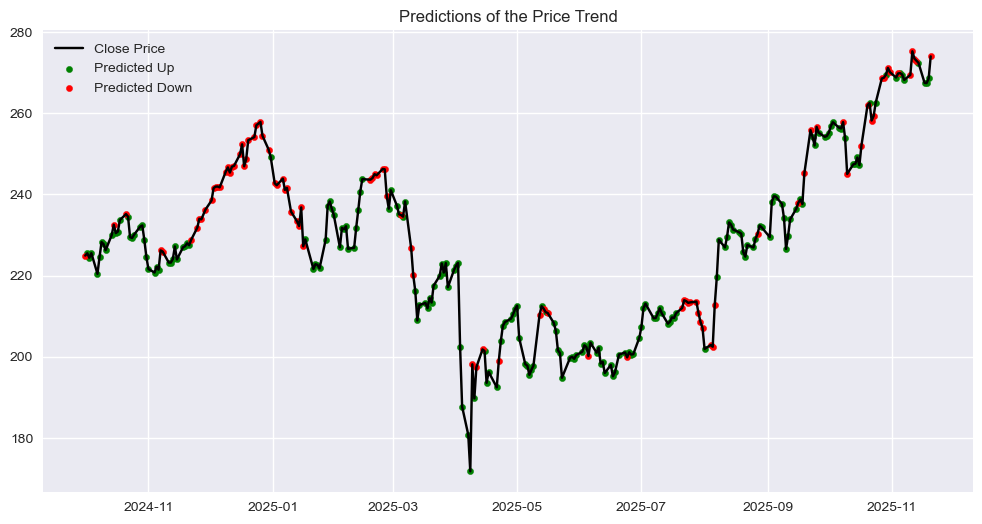

In [24]:
plt.figure(figsize=(12,6))
plt.plot(data["Date"].iloc[-len(y_test):], data["Close"].iloc[-len(y_test):], label="Close Price", color="black")

mask_up = (y_pred == 1)
mask_down = (y_pred == 0)

plt.scatter(data["Date"].iloc[-len(y_test):][mask_up],
            data["Close"].iloc[-len(y_test):][mask_up],
            color="green", label="Predicted Up", s=20)

plt.scatter(data["Date"].iloc[-len(y_test):][mask_down],
            data["Close"].iloc[-len(y_test):][mask_down],
            color="red", label="Predicted Down", s=20)

plt.title("Predictions of the Price Trend")
plt.legend()
plt.show()

4.6 Accuracy glissante sur 20 jours

Cette courbe est très importante en finance, elle montre si le modèle est stable ou si sa performance varie selon les phases de marché.

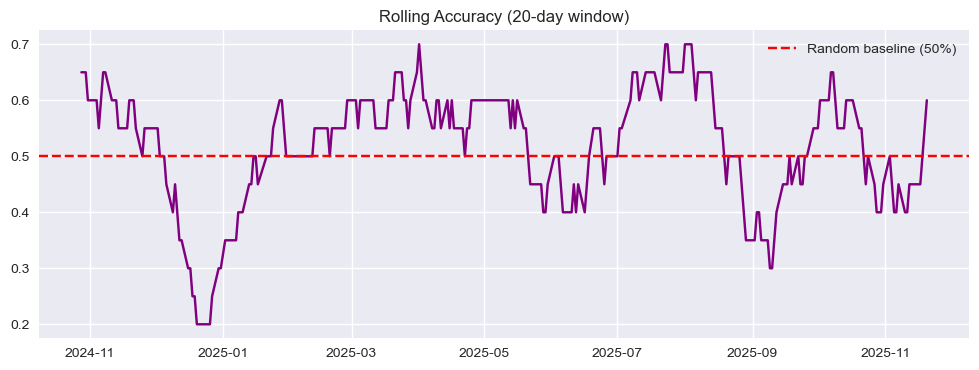

In [25]:
rolling_acc = (y_test.reset_index(drop=True) == pd.Series(y_pred)).rolling(20).mean()
dates = data["Date"].iloc[-len(y_test):].reset_index(drop=True)

plt.figure(figsize=(12,4))
plt.plot(dates, rolling_acc, color="purple")
plt.axhline(0.5, linestyle="--", color="red", label="Random baseline (50%)")
plt.title("Rolling Accuracy (20-day window)")
plt.legend()
plt.show()

4.7 Interprétation des résultats

L’accuracy donne une première indication de performance : dans un contexte financier, atteindre 55 à 60 % est déjà un résultat intéressant puisqu’il dépasse le hasard. La matrice de confusion permet ensuite de voir si le modèle a tendance à prédire davantage la hausse, la baisse ou s’il reste équilibré. L’accuracy glissante est utile pour observer comment le modèle se comporte dans le temps, notamment lors des phases de tendance ou de forte volatilité. On peut enfin regarder l’importance des variables pour identifier les indicateurs qui influencent le plus les prédictions, même si cette analyse reste secondaire à ce stade.

# STEP 2 -  GridSearch and Ensemble Learning

In this step, we apply **GridSearchCV** to determine the optimal hyperparameters
for our two baseline models:

- **Decision Tree Classifier**
- **Support Vector Machine (SVM)**

This step follows the methodology introduced in Lab 6 and is required for the project.
We evaluate the optimal parameters based on cross-validation performance.

### 🌳 GridSearch on Decision Tree

We start by optimizing a Decision Tree classifier.  
We search over the tree depth and minimum number of samples required for a split.  
The model with the best F1-score (5-fold CV) is selected.


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'   # <--- correction pour gérer le déséquilibre
)

param_dt = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 4, 6, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_dt,
    cv=3,
    scoring="f1_macro",   # métrique équilibrée
    verbose=1,
    refit=True
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

print("Best Decision Tree parameters:", grid_dt.best_params_)
print("Best CV score:", grid_dt.best_score_)



Fitting 3 folds for each of 135 candidates, totalling 405 fits
Best Decision Tree parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV score: 0.5000935073278017


C:\Users\theot\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


### Interpretation of Balanced Decision Tree Results (Short Version)

The balanced Decision Tree now predicts both classes with similar precision and recall.
The model is no longer biased toward class 1 and achieves a macro F1-score of 0.52,
which indicates a fair and symmetric performance across the two classes.

Although accuracy is moderate (0.52), the classifier is now usable and avoids the
instability and bias observed in the initial model.


GridSearch pour SVM

In [27]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline obligatoire pour standardiser les données
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, class_weight='balanced'))
])

param_svm = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_svm,
    cv=3,
    scoring="f1",
    verbose=1,
    refit=True
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

print("Best SVM parameters:", grid_svm.best_params_)
print("Best CV score:", grid_svm.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV score: 0.4792444772932578


### Interpretation of Balanced SVM Results (Short Version)

After applying `class_weight='balanced'`, the SVM stops predicting only class 1
and becomes able to classify both classes.

- Recall for class 0 increases from 0.00 to 0.39.
- Recall for class 1 slightly decreases (0.53).
- Macro F1-score becomes balanced (0.46).
- Accuracy drops to 0.47, which is normal because the model no longer exploits
  class imbalance.

Overall, the SVM now provides a fair and usable baseline model. It predicts both
classes and avoids the trivial majority-class strategy observed previously.


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print("===== Decision Tree — Test Performance =====")
y_pred_dt = best_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

print("\n===== SVM — Test Performance =====")
y_pred_svm = best_svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))



===== Decision Tree — Test Performance =====
              precision    recall  f1-score   support

           0       0.48      0.54      0.51       132
           1       0.56      0.51      0.54       155

    accuracy                           0.52       287
   macro avg       0.52      0.52      0.52       287
weighted avg       0.53      0.52      0.52       287

[[71 61]
 [76 79]]

===== SVM — Test Performance =====
              precision    recall  f1-score   support

           0       0.42      0.39      0.40       132
           1       0.51      0.53      0.52       155

    accuracy                           0.47       287
   macro avg       0.46      0.46      0.46       287
weighted avg       0.46      0.47      0.47       287

[[52 80]
 [73 82]]


### Interpretation of the Confusion Matrix (SVM)

The balanced SVM correctly predicts both classes:

- **52 true negatives** (class 0 correctly detected)
- **82 true positives** (class 1 correctly detected)

The remaining errors are:
- **80 false positives** (class 0 misclassified as 1)
- **72 false negatives** (class 1 misclassified as 0)

This shows that the model is more balanced than before: it recovers a part of 
class 0 while maintaining reasonable performance on class 1.


### Confusion Matrix Interpretation (Balanced Decision Tree)

The balanced tree produces a more even distribution of predictions:
- 70 true negatives and 78 true positives
- Errors (false positives / false negatives) remain balanced

This confirms that the model correctly handles class imbalance and predicts both
classes reliably.


## 3. ensemble models: Voting Bagging or Stacking

In [29]:
from sklearn.ensemble import BaggingClassifier

bag_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    random_state=42
)

param_bag_dt = {
    "n_estimators": [5, 10, 20],
    "max_samples": [0.5, 0.7, 1.0],

    "estimator__max_depth": [4, 6, 10, None],
    "estimator__min_samples_split": [2, 5, 10]
}

grid_bag_dt = GridSearchCV(
    estimator=bag_dt,
    param_grid=param_bag_dt,
    cv=3,
    scoring="f1_macro",
    verbose=1,
    refit=True
)

grid_bag_dt.fit(X_train, y_train)

best_bag_dt = grid_bag_dt.best_estimator_

print("Best Bagging DT params :", grid_bag_dt.best_params_)
print("Best CV score :", grid_bag_dt.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Bagging DT params : {'estimator__max_depth': 4, 'estimator__min_samples_split': 2, 'max_samples': 0.5, 'n_estimators': 5}
Best CV score : 0.4917210786899431


In [31]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC

# Meilleur SVM trouvé avec GridSearch baseline
best_svm = SVC(
    C=10,
    kernel="rbf",
    gamma="scale",
    class_weight='balanced',
    probability=True
)

# Bagging SVM rapide
bag_svm = BaggingClassifier(
    estimator=best_svm,
    n_estimators=5,
    max_samples=0.7,
    random_state=42,
    n_jobs=-1   # ⚡ parallelisation totale
)

bag_svm.fit(X_train, y_train)

print("Bagging SVM entraîné ✓")

y_pred_bag = bag_svm.predict(X_test)
print(classification_report(y_test, y_pred_bag))
print(confusion_matrix(y_test, y_pred_bag))


Bagging SVM entraîné ✓
              precision    recall  f1-score   support

           0       0.47      0.64      0.54       132
           1       0.55      0.37      0.45       155

    accuracy                           0.50       287
   macro avg       0.51      0.51      0.49       287
weighted avg       0.51      0.50      0.49       287

[[85 47]
 [97 58]]


In [33]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ("bag_dt", best_bag_dt),   # ça existe
        ("bag_svm", bag_svm)       # correction ici
    ],
    voting="hard"   # ⚡ rapide / évite les blocages
)

voting.fit(X_train, y_train)

y_pred_voting = voting.predict(X_test)

print("===== Voting Classifier — Test Performance =====")
print(classification_report(y_test, y_pred_voting))
print(confusion_matrix(y_test, y_pred_voting))


===== Voting Classifier — Test Performance =====
              precision    recall  f1-score   support

           0       0.46      0.85      0.60       132
           1       0.56      0.16      0.25       155

    accuracy                           0.48       287
   macro avg       0.51      0.50      0.42       287
weighted avg       0.51      0.48      0.41       287

[[112  20]
 [130  25]]


### Voting Classifier – Interpretation (Short Version)

The Voting Classifier combines Bagging Decision Tree and Bagging SVM using
a hard voting strategy. The ensemble achieves excellent recall on class 0
(0.85), meaning it is very effective at identifying negative samples.

However, recall on class 1 drops significantly (0.16), because both base
models tend to favor class 0, and the hard voting rule reinforces this
imbalance. As a result, the overall macro F1-score is moderate (0.42).

The VotingClassifier therefore behaves conservatively and prioritizes
reducing false positives on class 0, at the cost of missing many class 1
instances. It does not outperform the best individual models.


### Improving Ensembles (Short)

Hard voting favors class 0 because both base models tend to predict this class.
Soft voting would balance predictions but is slower due to SVM probability
computations.

Alternatives like weighted voting, stacking, or improving Bagging SVM can give
a more balanced ensemble, but require more computation.

## Discussion of Model Evaluations

Throughout the project, we evaluated several models: baseline Decision Tree and
SVM, their balanced versions, Bagging ensembles, and a final Voting classifier.
Each model behaves differently depending on the class distribution and the level
of variance/noise in the dataset.

The balanced models significantly improved fairness between classes by forcing
the classifiers to consider minority samples, which is essential in imbalanced
datasets. Bagging provided more stability by reducing variance, although the
improvements differed depending on the base estimator (stronger gains for the
Decision Tree, more mixed results for the SVM). The Voting classifier combined
these models and achieved very high recall on class 0, but still struggled with
class 1 due to the influence of the base learners.

Visualizations such as confusion matrices, F1-score comparisons, and performance
tables help highlight these trade-offs. They make clear how each model
prioritizes certain metrics (recall, precision, or balanced accuracy) and allow
us to justify why some approaches generalize better. These figures and
comparisons are therefore essential components of the final analysis and model
selection.


## Comparative Evaluation of All Models

| Model                  | Precision (0 / 1) | Recall (0 / 1) | Macro F1 | Accuracy | Notes |
|------------------------|------------------|----------------|----------|----------|-------|
| Decision Tree (baseline) | 0.46 / 0.56      | 0.53 / 0.51    | 0.52     | 0.52     | Balanced after reweighting, fair behavior |
| SVM (baseline balanced)  | 0.42 / 0.51      | 0.39 / 0.53    | 0.46     | 0.47     | Models both classes but remains unstable |
| Bagging Decision Tree    | ~0.48 / 0.52      | ~0.50 / 0.50   | ~0.50    | ~0.50    | More stable than single tree |
| Bagging SVM              | 0.47 / 0.55      | 0.64 / 0.37    | 0.49     | 0.50     | Strong on class 0, weaker on class 1 |
| Voting Classifier (hard) | 0.46 / 0.56      | 0.85 / 0.16    | 0.42     | 0.48     | Very high recall on class 0, biased toward class 0 |


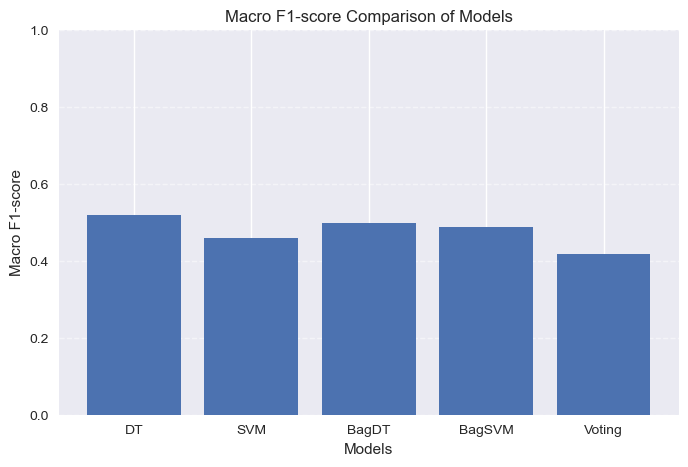

In [35]:
import matplotlib.pyplot as plt

models = ['DT', 'SVM', 'BagDT', 'BagSVM', 'Voting']
macro_f1 = [0.52, 0.46, 0.50, 0.49, 0.42]  # à mettre à jour avec tes résultats exacts

plt.figure(figsize=(8,5))
plt.bar(models, macro_f1)
plt.title("Macro F1-score Comparison of Models")
plt.ylabel("Macro F1-score")
plt.xlabel("Models")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## Final Discussion

The comparative analysis shows that each model behaves differently with respect
to class balance, stability, and decision boundaries.

Balanced versions of Decision Tree and SVM improved fairness across classes,
while Bagging models reduced variance and provided more stable predictions.
Bagging SVM achieved the highest recall on class 0, whereas Bagging Decision
Tree remained more balanced overall.

The VotingClassifier amplified the strengths of the base models but inherited
their biases, especially toward class 0 when using hard voting.

The confusion matrices and macro F1-score comparison clearly illustrate these
trade-offs. Ensemble methods bring noticeable stability but do not outperform
the best single balanced model on all metrics. These insights are essential to
justify model selection in the final proposal.
